# Macroscopic stigmatic field: a bounded local spectrum
A 10 mm curvature-radius conic at 193.368 nm. All amplitudes originate in
per-k Fresnel boundary traces. The acceleration expands the existing radiation
locally about the observation centre; it does not supply an ideal-pupil field.
The kernel error, quadrature error and unresolved dielectric-boundary error
are distinct. See `docs/macroscopic_fields.md` for the derivation and bound.

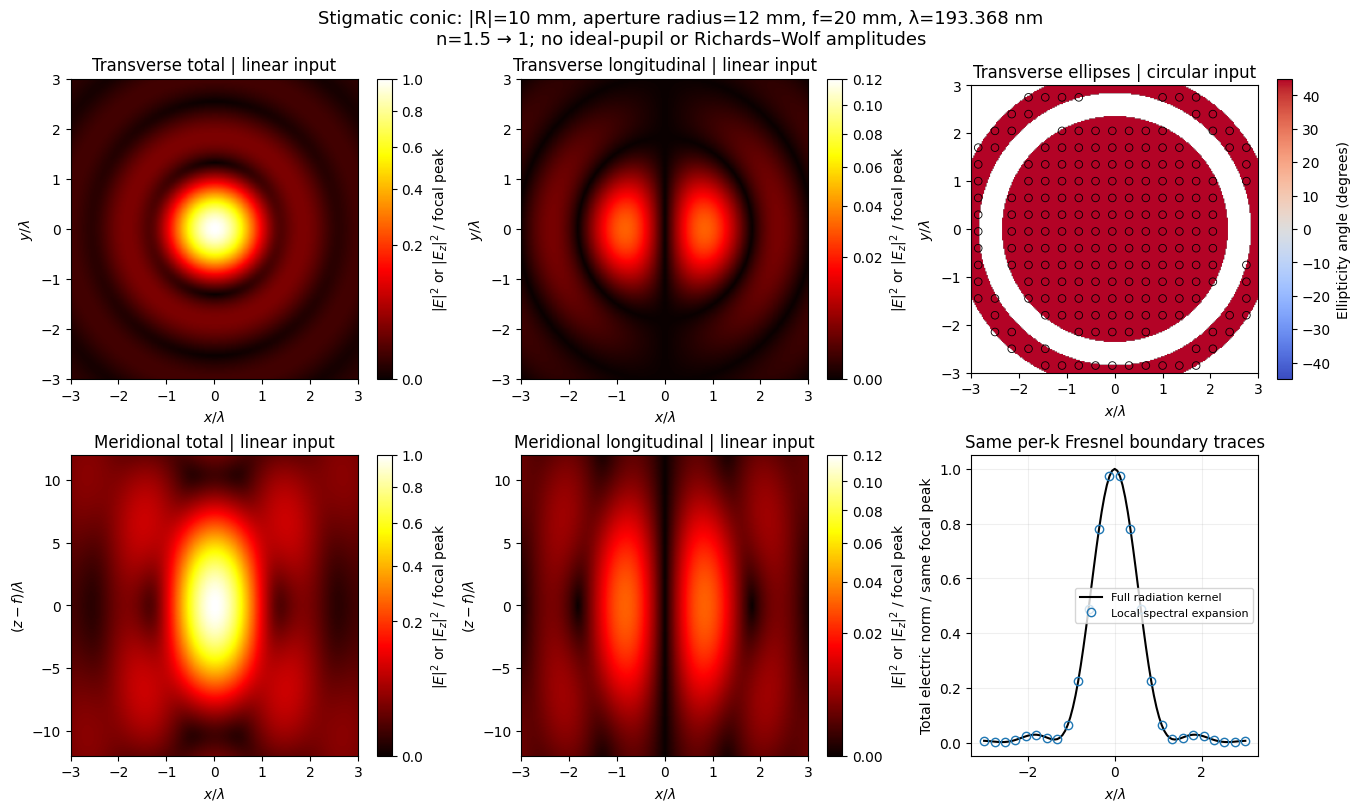

{'observation_ball_radius_wavelengths': 13,
 'wavelength_mm': 0.000193368,
 'radius_mm': 10.0,
 'radius_over_wavelength': 51714.86492077283,
 'aperture_radius_mm': 12.0,
 'focus_mm': 20.0,
 'source_nodes': 2048,
 'transverse_shape': [241, 241],
 'meridional_shape': [301, 241],
 'construction_seconds': 0.006915203999994901,
 'field_maps_seconds': 0.6254377610000006,
 'reference_points_seconds': 0.05929673299999649,
 'kernel_relative_EH_error': 0.00010316656465965047,
 'surface_quadrature_relative_EH_change': 1.487330871773995e-11,
 'nufft_relative_EH_error': 8.923973455218599e-11,
 'electric_absolute_error_bound': 602.4625181591459,
 'magnetic_absolute_error_bound': 602.1869834084325,
 'electric_error_bound_over_peak_amplitude': 0.0062018137190353794,
 'longitudinal_norm_fraction': 0.05374350542244338,
 'parameters': {'indices': [1.5, 1.0],
  'conic': -2.25,
  'source_quadrature': [32, 64],
  'length_unit': 'mm'},
 'assumptions': ['Local expansion of the existing Fresnel-current radiati

In [1]:
from pathlib import Path
import sys
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
sys.path.insert(0, str(root))
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
from examples.macroscopic_focus import run
figure, report = run()
display(figure)
plt.close(figure)
report

## Independent scale and quadrature controls
These committed measurements compare against radiation by the same Fresnel
currents, not a globally solved dielectric boundary. Rerun with
`python -m benchmarks.macroscopic_focus`. A small focal window is essential.

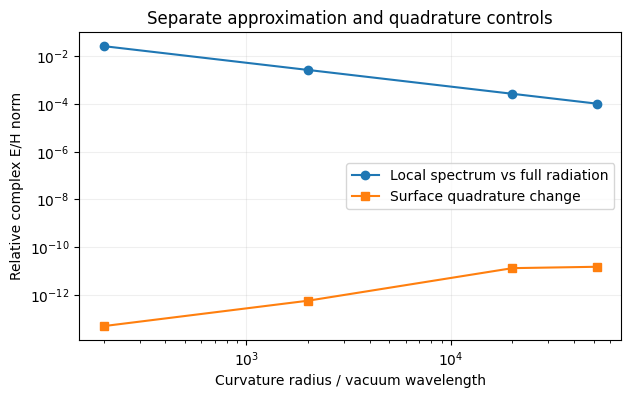

[{'radius_over_wavelength': 200.0,
  'radius_mm': 0.0386736,
  'construction_seconds': 0.005277879001369001,
  'spectral_sample_seconds': 0.00356212499900721,
  'reference_sample_seconds': 0.03617786399991019,
  'relative_EH_kernel_error': 0.026618468085376278,
  'radial_quadrature_change': 6.171256656245111e-14,
  'azimuthal_quadrature_change': 3.7596925896788806e-14,
  'combined_quadrature_change': 4.8285003581291664e-14,
  'electric_absolute_bound': 619.3159477005242,
  'magnetic_absolute_bound': 619.0332362209384},
 {'radius_over_wavelength': 2000.0,
  'radius_mm': 0.38673599999999997,
  'construction_seconds': 0.004411232999700587,
  'spectral_sample_seconds': 0.0027098210011899937,
  'reference_sample_seconds': 0.032300774997565895,
  'relative_EH_kernel_error': 0.0026675647245904544,
  'radial_quadrature_change': 5.939106173999186e-13,
  'azimuthal_quadrature_change': 4.031515889449576e-13,
  'combined_quadrature_change': 5.61362221272357e-13,
  'electric_absolute_bound': 604.04

In [2]:
import json
import numpy as np
results = json.loads((root/'benchmarks/results/macroscopic_focus.json').read_text())
cases = results['cases']
fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog([r['radius_over_wavelength'] for r in cases], [r['relative_EH_kernel_error'] for r in cases], 'o-', label='Local spectrum vs full radiation')
ax.loglog([r['radius_over_wavelength'] for r in cases], [r['combined_quadrature_change'] for r in cases], 's-', label='Surface quadrature change')
ax.set(xlabel='Curvature radius / vacuum wavelength', ylabel='Relative complex E/H norm', title='Separate approximation and quadrature controls')
ax.legend(); ax.grid(alpha=.2)
display(fig); plt.close(fig)
cases

## A real DUV prescription, imported without dropping encounters
This demonstrates IO of all 48 encounters, including a folded branch and
the stop. The present ordered dielectric propagator cannot execute this full
prescription; parsing it does not supply mirror coating amplitudes or phases.

48 encounters; wavelength=193.368 nm; image z=1423.077700 mm
Mirrors: [7, 10]


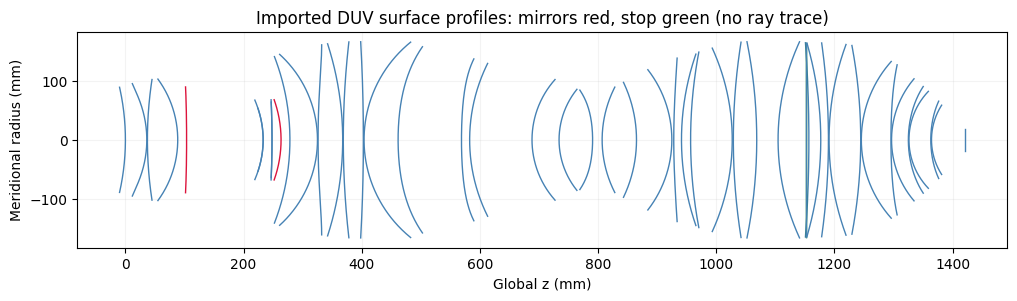

In [3]:
from vecdiff.IO import read_prescription
system = read_prescription(root/'examples/data/US7557996.csv')
print(f'{len(system.encounters)} encounters; wavelength={system.wavelength*1e6:.3f} nm; image z={system.image_z:.6f} mm')
print('Mirrors:', [e.number for e in system.encounters if e.interaction == 'reflect'])
fig,ax=plt.subplots(figsize=(12,4))
for encounter in system.encounters:
    surface=encounter.surface; radius=encounter.semidiameter
    r=np.linspace(-radius,radius,201)
    sag=surface.sag(abs(r)) if hasattr(surface,'sag') else r*0
    ax.plot(surface.frame.origin[2]+sag,r,color={'reflect':'crimson','stop':'green','refract':'steelblue'}[encounter.interaction],lw=1)
ax.set(xlabel='Global z (mm)',ylabel='Meridional radius (mm)',title='Imported DUV surface profiles: mirrors red, stop green (no ray trace)')
ax.set_aspect('equal'); ax.grid(alpha=.15)
display(fig);plt.close(fig)